# Code to analyze CAMELS-CL data for the Itata Basin (Nevados de Chillán)
## Precipitation, temperature, streamflow, and water rights sales 
### all CAMELS-CL basin data is freely available here: https://camels.cr2.cl/

CAMELS-CL Data Citation: 
Alvarez-Garreton, C., Mendoza, P. A., Boisier, J. P., Addor, N., Galleguillos, M., Zambrano-Bigiarini, M., Lara, A., Puelma, C., Cortes, G., Garreaud, R., McPhee, J., and Ayala, A.: The CAMELS-CL dataset: catchment attributes and meteorology for large sample studies – Chile dataset, Hydrol. Earth Syst. Sci., 22, 5817-5846, https://doi.org/10.5194/hess-22-5817-2018 , 2018.

In [42]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.linear_model import LinearRegression
from datetime import datetime
import seaborn as sns
from scipy.stats import linregress

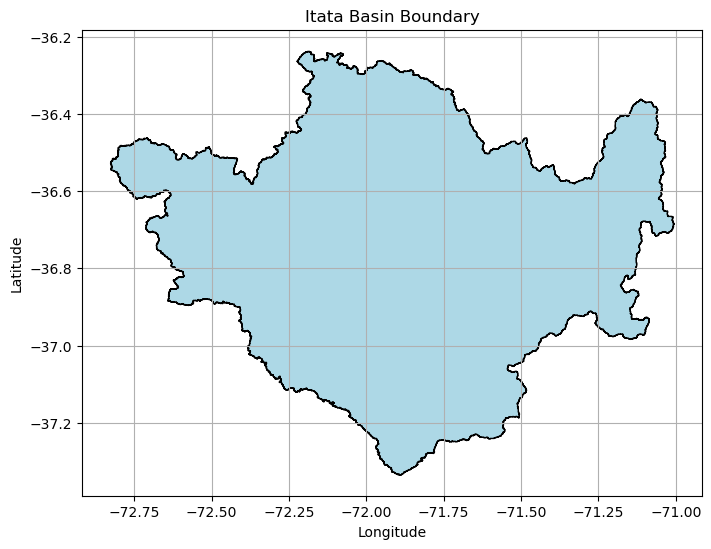

In [34]:
# path to basin shapefile
shapefile_path = '/Users/milliespencer/Downloads/camels_cl_8141001/polygon/polygon.shp'

# Load the shapefile using GeoPandas
basin_gdf = gpd.read_file(shapefile_path)

# Plot the basin polygon
fig, ax = plt.subplots(figsize=(8, 8))
basin_gdf.plot(ax=ax, color='lightblue', edgecolor='black')

# Add plot settings
ax.set_title("Itata Basin Boundary")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)

# Show the plot
plt.show()


In [ ]:
# File paths for your CAMELS basin data

#precipitation data
daily_precip_chirps = '/Users/milliespencer/Downloads/camels_cl_8141001/precip_chirps_day.csv'
monthly_precip_chirps = '/Users/milliespencer/Downloads/camels_cl_8141001/precip_chirps_mon.csv'
daily_precip_cr2 = '/Users/milliespencer/Downloads/camels_cl_8141001/precip_cr2met_day.csv'
monthly_precip_cr2 = '/Users/milliespencer/Downloads/camels_cl_8141001/precip_cr2met_mon.csv'

#temperature data 
tmax_daily = '/Users/milliespencer/Downloads/camels_cl_8141001/tmax_cr2met_day.csv'
tmax_monthly = '/Users/milliespencer/Downloads/camels_cl_8141001/tmax_cr2met_mon.csv'
tmin_daily = '/Users/milliespencer/Downloads/camels_cl_8141001/tmin_cr2met_day.csv'
tmin_monthly = '/Users/milliespencer/Downloads/camels_cl_8141001/tmin_cr2met_mon.csv'

#streamflow data 
streamflow_daily = '/Users/milliespencer/Downloads/camels_cl_8141001/q_m3s_day.csv'
streamflow_monthly = '/Users/milliespencer/Downloads/camels_cl_8141001/q_m3s_mon.csv'

#water rights
groundwater_rights = '/Users/milliespencer/Downloads/camels_cl_8141001/cons_gw_wr_year.csv'
surface_rights = '/Users/milliespencer/Downloads/camels_cl_8141001/cons_sf_wr_year.csv'

# Column name used for the basin values in all CSVs
basin_col = '8141001'

# Column that contains dates
date_column = 'date'

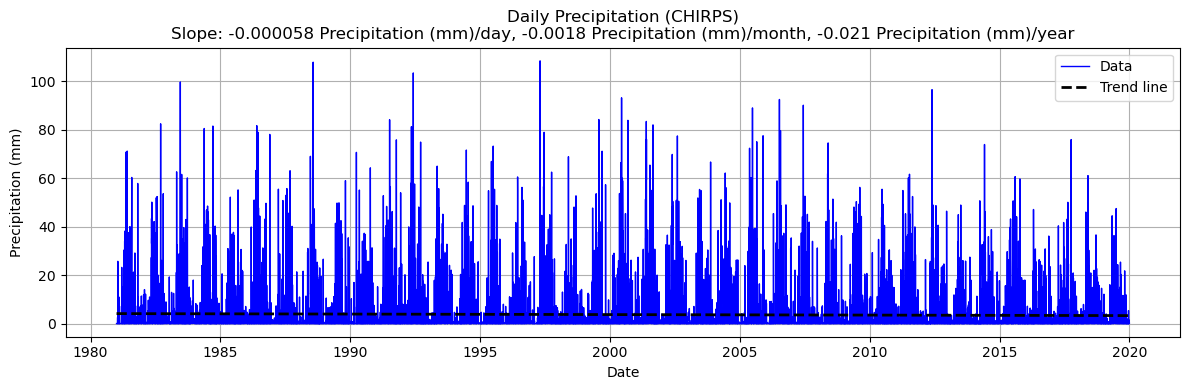

Daily Precipitation (CHIRPS) slopes:
 - per day:   -0.000058 Precipitation (mm)/day
 - per month: -0.0018 Precipitation (mm)/month
 - per year:  -0.021 Precipitation (mm)/year


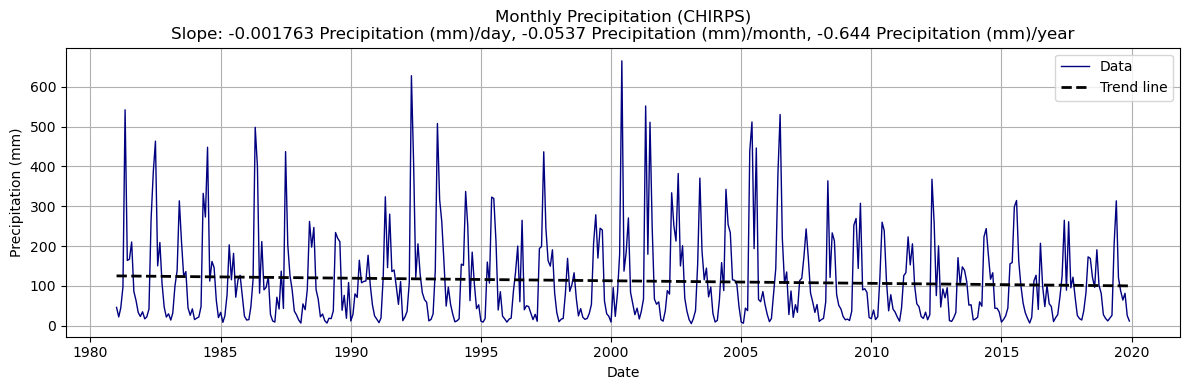

Monthly Precipitation (CHIRPS) slopes:
 - per day:   -0.001763 Precipitation (mm)/day
 - per month: -0.0537 Precipitation (mm)/month
 - per year:  -0.644 Precipitation (mm)/year


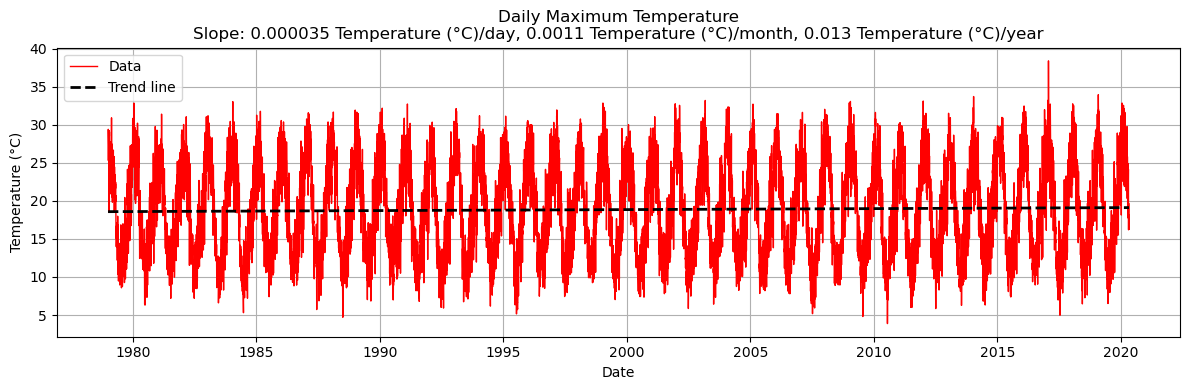

Daily Maximum Temperature slopes:
 - per day:   0.000035 Temperature (°C)/day
 - per month: 0.0011 Temperature (°C)/month
 - per year:  0.013 Temperature (°C)/year


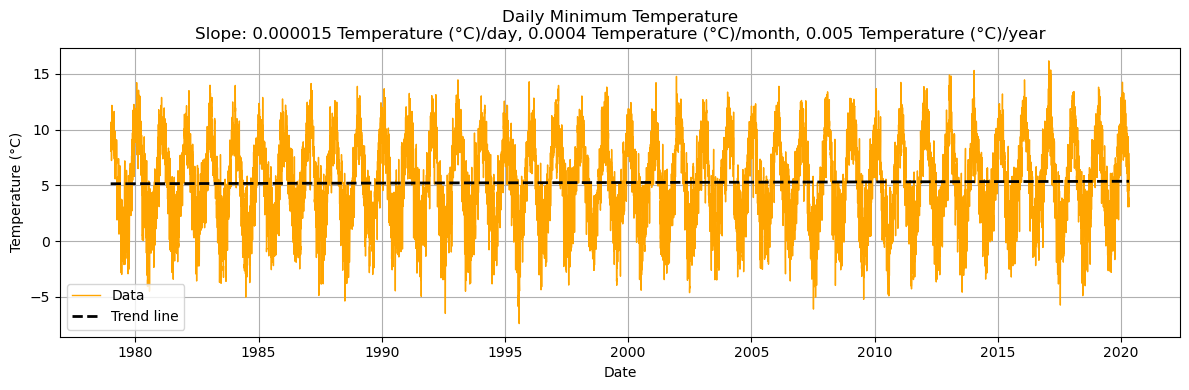

Daily Minimum Temperature slopes:
 - per day:   0.000015 Temperature (°C)/day
 - per month: 0.0004 Temperature (°C)/month
 - per year:  0.005 Temperature (°C)/year


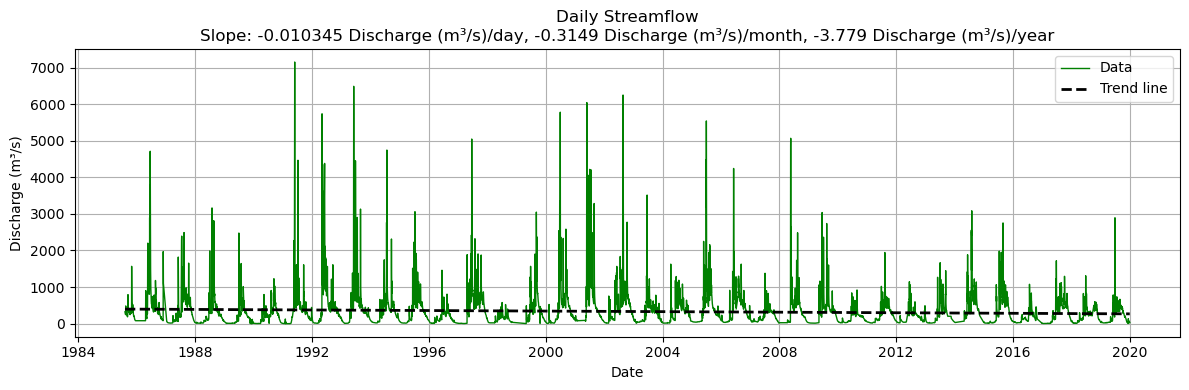

Daily Streamflow slopes:
 - per day:   -0.010345 Discharge (m³/s)/day
 - per month: -0.3149 Discharge (m³/s)/month
 - per year:  -3.779 Discharge (m³/s)/year


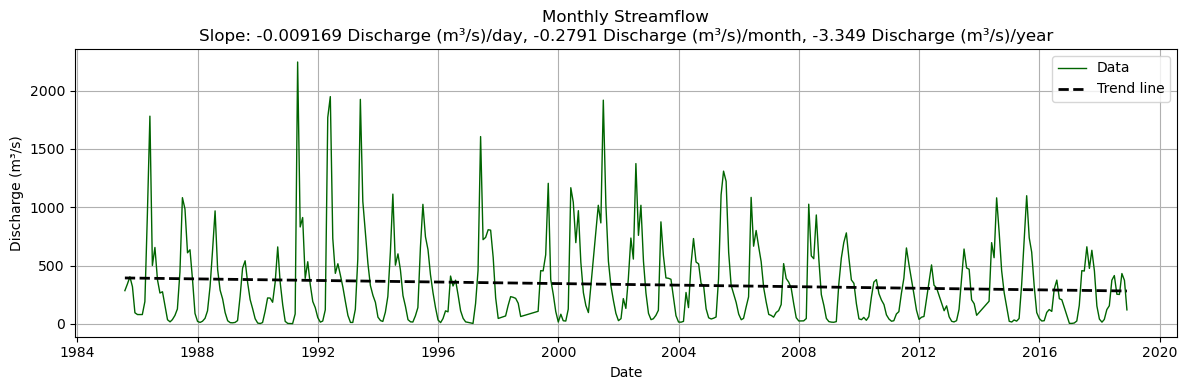

Monthly Streamflow slopes:
 - per day:   -0.009169 Discharge (m³/s)/day
 - per month: -0.2791 Discharge (m³/s)/month
 - per year:  -3.349 Discharge (m³/s)/year


In [15]:
# ------------- FUNCTIONS -------------

def load_and_prepare(file, basin_col, new_colname):
    """Load CSV, rename basin column, parse dates, and set index."""
    df = pd.read_csv(file)
    df[date_column] = pd.to_datetime(df[date_column])  # auto format detection, e.g. '1979-01-01'
    df = df.rename(columns={basin_col: new_colname})
    df = df[[date_column, new_colname]].dropna()
    df.set_index(date_column, inplace=True)
    return df

def plot_time_series_with_trend(df, title, ylabel, color):
    """
    Plot time series with a linear trend line and print slopes per day, month, and year.
    """
    plt.figure(figsize=(12, 4))
    
    # Plot original data
    plt.plot(df.index, df.iloc[:, 0], color=color, linewidth=1, label='Data')
    
    # Prepare data for regression: convert dates to ordinal numbers
    x = df.index.map(pd.Timestamp.toordinal).values.reshape(-1, 1)
    y = df.iloc[:, 0].values.reshape(-1, 1)
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(x, y)
    slope_per_day = model.coef_[0][0]
    intercept = model.intercept_[0]
    
    # Convert slopes
    days_per_month = 30.44
    days_per_year = 365.25
    slope_per_month = slope_per_day * days_per_month
    slope_per_year = slope_per_day * days_per_year
    
    # Create trend line
    y_trend = model.predict(x)
    plt.plot(df.index, y_trend, color='black', linestyle='--', linewidth=2, label='Trend line')
    
    # Labels and legend
    plt.title(
        f"{title}\n"
        f"Slope: {slope_per_day:.6f} {ylabel}/day, "
        f"{slope_per_month:.4f} {ylabel}/month, "
        f"{slope_per_year:.3f} {ylabel}/year"
    )
    plt.xlabel('Date')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    print(f"{title} slopes:")
    print(f" - per day:   {slope_per_day:.6f} {ylabel}/day")
    print(f" - per month: {slope_per_month:.4f} {ylabel}/month")
    print(f" - per year:  {slope_per_year:.3f} {ylabel}/year")

# ------------- LOAD DATA -------------

# Precipitation
precip_daily = load_and_prepare(daily_precip_chirps, basin_col, 'Precipitation CHIRPS (mm/day)')
precip_monthly = load_and_prepare(monthly_precip_chirps, basin_col, 'Precipitation CHIRPS (mm/month)')

# Temperature
tmax = load_and_prepare(tmax_daily, basin_col, 'Tmax (°C)')
tmin = load_and_prepare(tmin_daily, basin_col, 'Tmin (°C)')

# Streamflow
streamflow = load_and_prepare(streamflow_daily, basin_col, 'Streamflow (m³/s)')
streamflow_month = load_and_prepare(streamflow_monthly, basin_col, 'Monthly Streamflow (m³/s)')

# ------------- PLOT TIME SERIES WITH TRENDS -------------

plot_time_series_with_trend(precip_daily, 'Daily Precipitation (CHIRPS)', 'Precipitation (mm)', 'blue')
plot_time_series_with_trend(precip_monthly, 'Monthly Precipitation (CHIRPS)', 'Precipitation (mm)', 'navy')

plot_time_series_with_trend(tmax, 'Daily Maximum Temperature', 'Temperature (°C)', 'red')
plot_time_series_with_trend(tmin, 'Daily Minimum Temperature', 'Temperature (°C)', 'orange')

plot_time_series_with_trend(streamflow, 'Daily Streamflow', 'Discharge (m³/s)', 'green')
plot_time_series_with_trend(streamflow_month, 'Monthly Streamflow', 'Discharge (m³/s)', 'darkgreen')


## Now want to express temporal changes as percent change 

--- Daily Precipitation CHIRPS ---


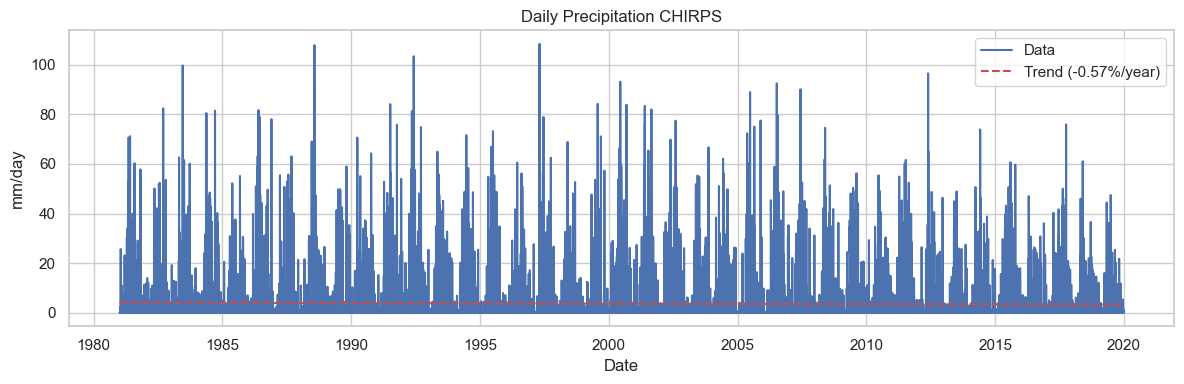

Daily Precipitation CHIRPS — Mean: 3.704 mm/day
Percent change per year (linear fit): -0.572%
Mean pre-2000: 3.736 mm/day
Mean post-2000: 3.674 mm/day
Percent difference (post2000 vs pre2000): -1.659%

Percent changes between consecutive decades:
  1980s to 1990s: -0.252%
  1990s to 2000s: 15.772%
  2000s to 2010s: -29.913%

----------------------------------------

--- Monthly Precipitation CHIRPS ---


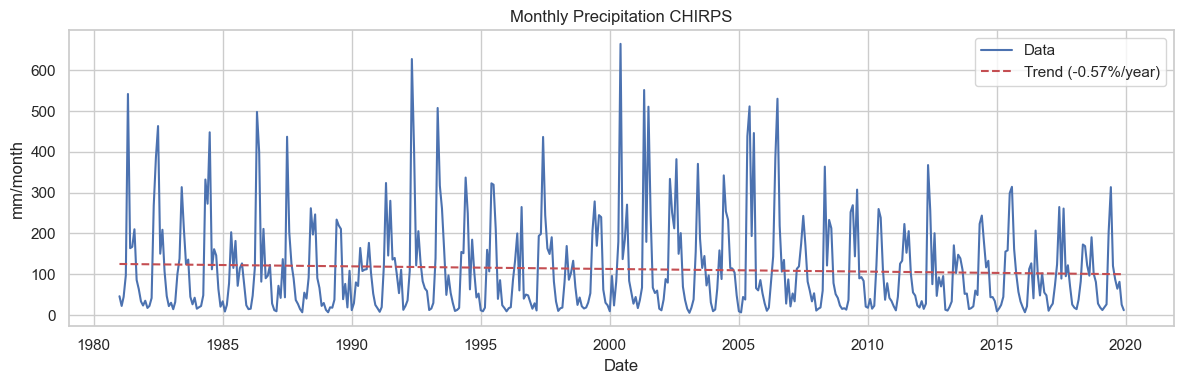

Monthly Precipitation CHIRPS — Mean: 112.735 mm/month
Percent change per year (linear fit): -0.571%
Mean pre-2000: 113.696 mm/month
Mean post-2000: 111.823 mm/month
Percent difference (post2000 vs pre2000): -1.648%

Percent changes between consecutive decades:
  1980s to 1990s: -0.258%
  1990s to 2000s: 15.804%
  2000s to 2010s: -29.932%

----------------------------------------

--- Daily Precipitation CR2MET ---


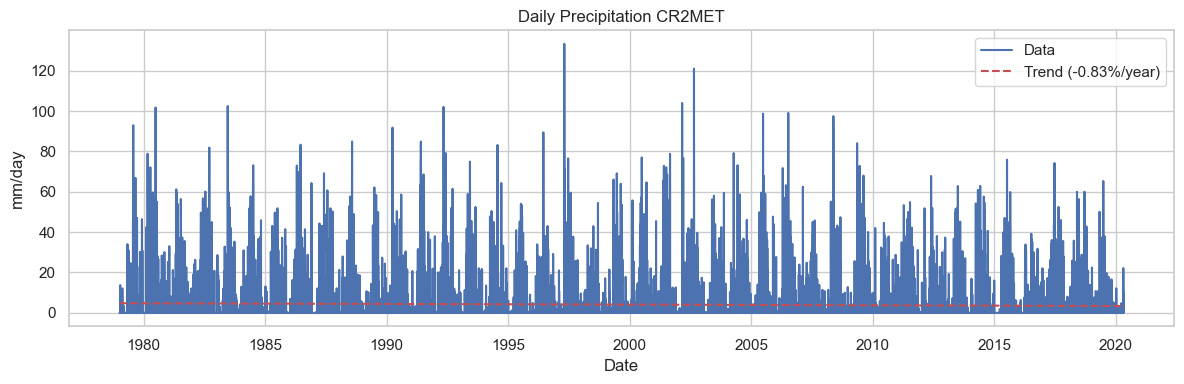

Daily Precipitation CR2MET — Mean: 4.065 mm/day
Percent change per year (linear fit): -0.827%
Mean pre-2000: 4.225 mm/day
Mean post-2000: 3.900 mm/day
Percent difference (post2000 vs pre2000): -7.688%

Percent changes between consecutive decades:
  1970s to 1980s: 2.305%
  1980s to 1990s: -14.039%
  1990s to 2000s: 13.041%
  2000s to 2010s: -20.523%
  2010s to 2020s: -79.217%

----------------------------------------

--- Monthly Precipitation CR2MET ---


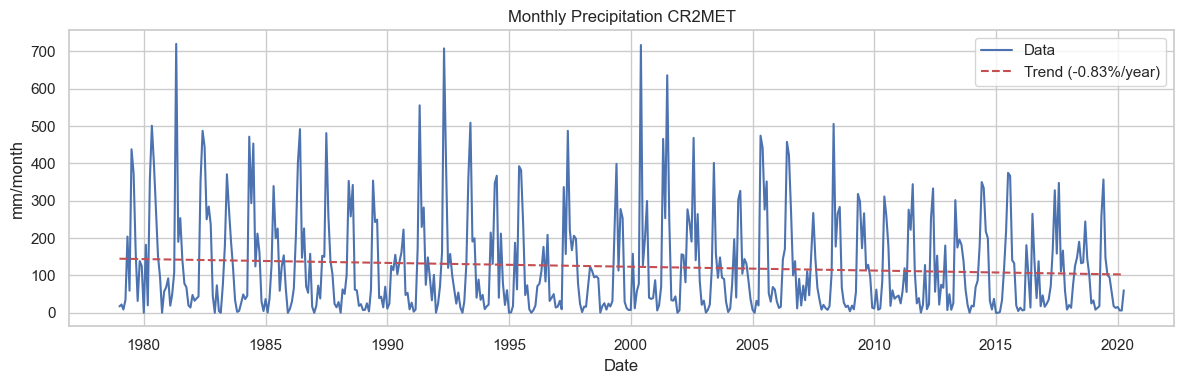

Monthly Precipitation CR2MET — Mean: 123.729 mm/month
Percent change per year (linear fit): -0.827%
Mean pre-2000: 128.597 mm/month
Mean post-2000: 118.702 mm/month
Percent difference (post2000 vs pre2000): -7.695%

Percent changes between consecutive decades:
  1970s to 1980s: 2.389%
  1980s to 1990s: -14.063%
  1990s to 2000s: 13.072%
  2000s to 2010s: -20.544%
  2010s to 2020s: -79.342%

----------------------------------------

--- Daily Max Temperature ---


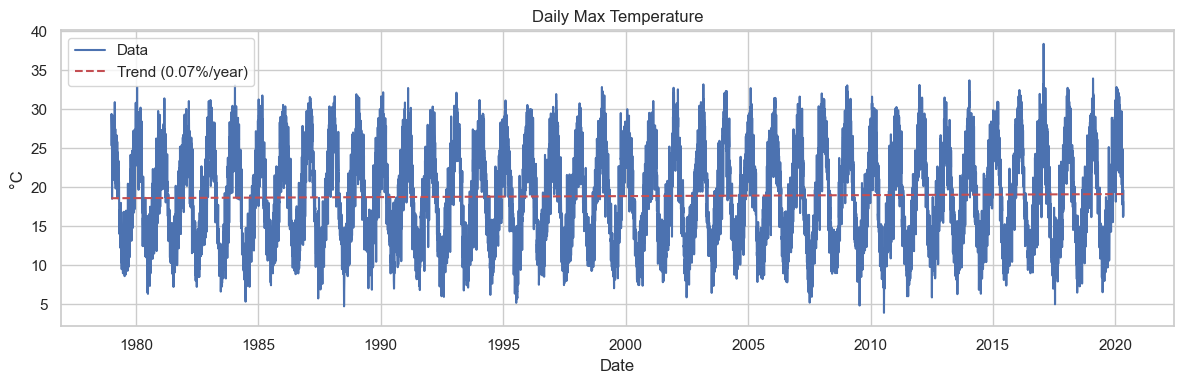

Daily Max Temperature — Mean: 18.853 °C
Percent change per year (linear fit): 0.068%
Mean pre-2000: 18.775 °C
Mean post-2000: 18.932 °C
Percent difference (post2000 vs pre2000): 0.837%

Percent changes between consecutive decades:
  1970s to 1980s: 0.466%
  1980s to 1990s: 0.350%
  1990s to 2000s: -0.689%
  2000s to 2010s: 1.431%
  2010s to 2020s: 36.427%

----------------------------------------

--- Daily Min Temperature ---


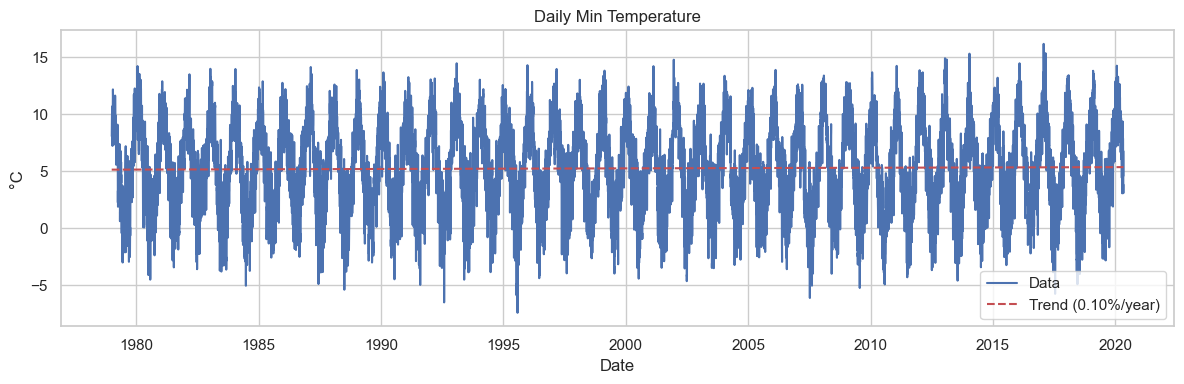

Daily Min Temperature — Mean: 5.249 °C
Percent change per year (linear fit): 0.102%
Mean pre-2000: 5.203 °C
Mean post-2000: 5.297 °C
Percent difference (post2000 vs pre2000): 1.809%

Percent changes between consecutive decades:
  1970s to 1980s: 3.125%
  1980s to 1990s: -0.494%
  1990s to 2000s: -0.542%
  2000s to 2010s: 2.521%
  2010s to 2020s: 71.873%

----------------------------------------

--- Daily Streamflow ---


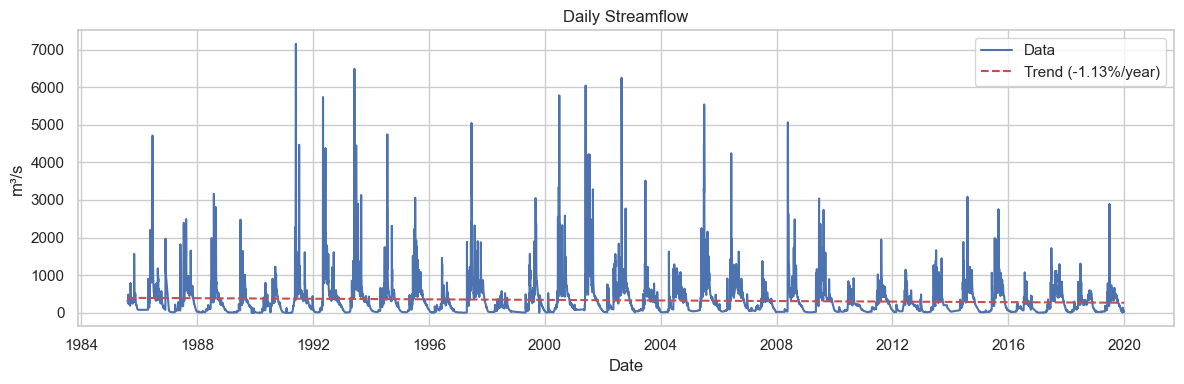

Daily Streamflow — Mean: 333.020 m³/s
Percent change per year (linear fit): -1.135%
Mean pre-2000: 356.346 m³/s
Mean post-2000: 316.646 m³/s
Percent difference (post2000 vs pre2000): -11.141%

Percent changes between consecutive decades:
  1980s to 1990s: 14.869%
  1990s to 2000s: 2.636%
  2000s to 2010s: -35.031%

----------------------------------------

--- Monthly Streamflow ---


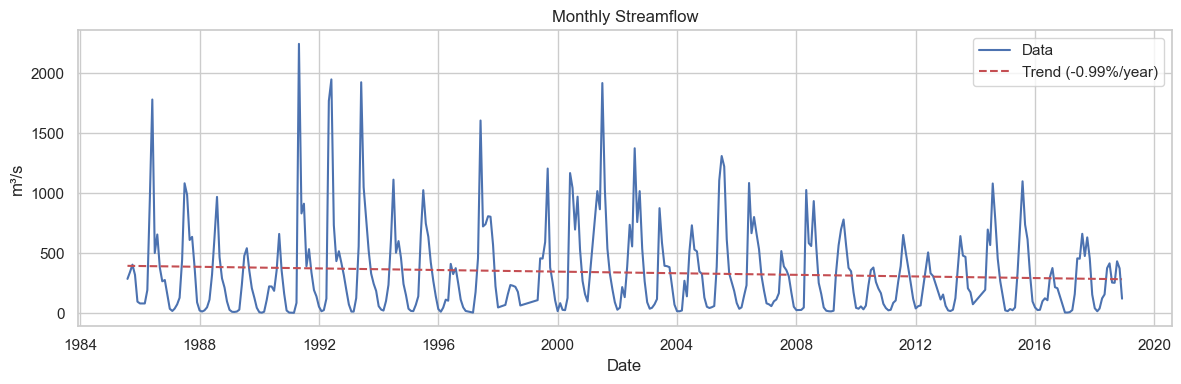

Monthly Streamflow — Mean: 338.307 m³/s
Percent change per year (linear fit): -0.990%
Mean pre-2000: 356.657 m³/s
Mean post-2000: 324.544 m³/s
Percent difference (post2000 vs pre2000): -9.004%

Percent changes between consecutive decades:
  1980s to 1990s: 18.851%
  1990s to 2000s: 2.304%
  2000s to 2010s: -33.996%

----------------------------------------

--- Annual Surface Water Rights ---


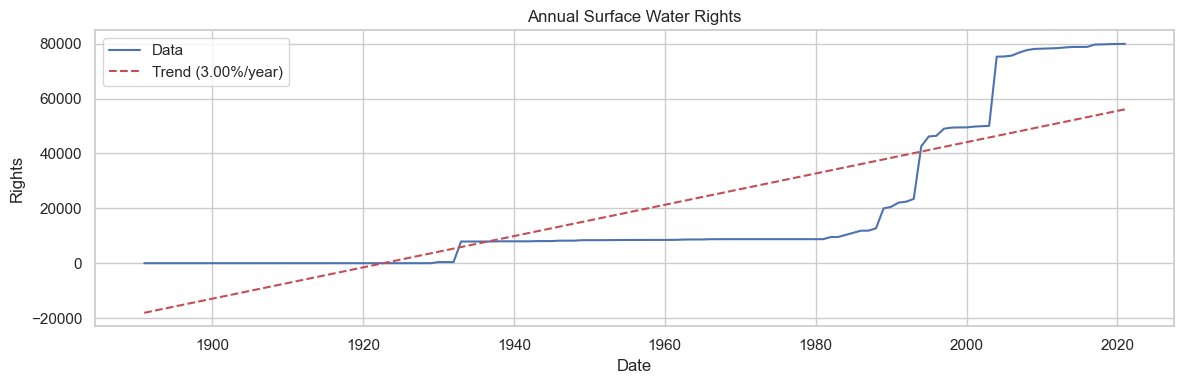

Annual Surface Water Rights — Mean: 19002.063 Rights
Percent change per year (linear fit): 3.002%
Mean pre-2000: 8093.188 Rights
Mean post-2000: 73050.578 Rights
Percent difference (post2000 vs pre2000): 802.618%

Percent changes between consecutive decades:
  1890s to 1900s: nan%
  1900s to 1910s: nan%
  1910s to 1920s: nan%
  1920s to 1930s: nan%
  1930s to 1940s: 43.186%
  1940s to 1950s: 4.074%
  1950s to 1960s: 2.411%
  1960s to 1970s: 1.267%
  1970s to 1980s: 30.625%
  1980s to 1990s: 224.938%
  1990s to 2000s: 77.086%
  2000s to 2010s: 19.929%
  2010s to 2020s: 1.273%

----------------------------------------

--- Annual Groundwater Water Rights ---


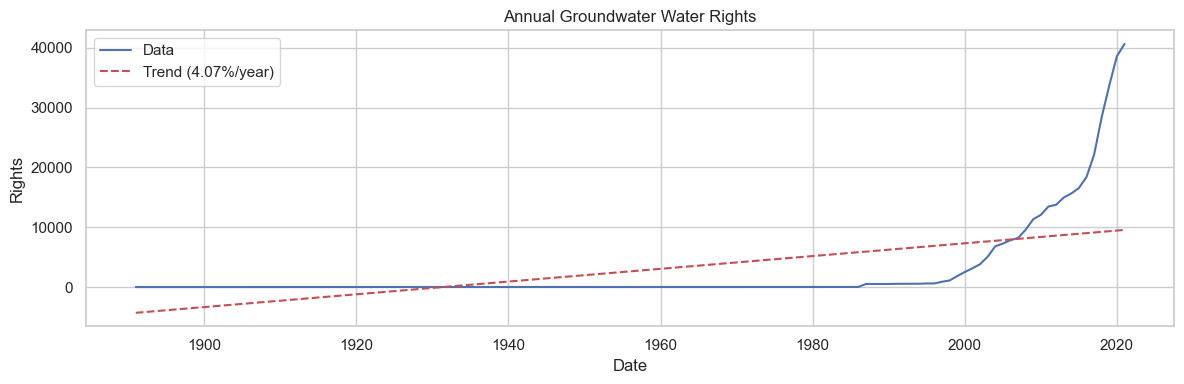

Annual Groundwater Water Rights — Mean: 2619.049 Rights
Percent change per year (linear fit): 4.068%
Mean pre-2000: 84.853 Rights
Mean post-2000: 15174.841 Rights
Percent difference (post2000 vs pre2000): 17783.739%

Percent changes between consecutive decades:
  1890s to 1900s: nan%
  1900s to 1910s: nan%
  1910s to 1920s: nan%
  1920s to 1930s: nan%
  1930s to 1940s: nan%
  1940s to 1950s: nan%
  1950s to 1960s: nan%
  1960s to 1970s: nan%
  1970s to 1980s: nan%
  1980s to 1990s: 394.153%
  1990s to 2000s: 752.064%
  2000s to 2010s: 188.483%
  2010s to 2020s: 109.494%

----------------------------------------



In [48]:

def load_data(filepath):
    df = pd.read_csv(filepath)
    df[date_column] = pd.to_datetime(df[date_column])
    df = df[[date_column, basin_col]].dropna()
    df = df.set_index(date_column)
    return df

def calculate_decade_means(df):
    df = df.copy()
    df['decade'] = (df.index.year // 10) * 10
    decade_means = df.groupby('decade')[basin_col].mean()
    return decade_means

def plot_percent_change(df, title, ylabel):
    df = df.sort_index()
    y = df[basin_col]
    x = (df.index - df.index[0]).days.values  # days since start
    
    # Linear regression for annual slope
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    mean_val = y.mean()
    pct_change_per_year = (slope * 365.25) / mean_val * 100
    
    # Means pre/post 2000
    pre_2000_mean = y[df.index < '2000-01-01'].mean()
    post_2000_mean = y[df.index >= '2000-01-01'].mean()
    pct_diff_pre_post_2000 = ((post_2000_mean - pre_2000_mean) / pre_2000_mean) * 100 if pre_2000_mean != 0 else float('nan')
    
    # Calculate actual percent changes between decades
    decade_means = calculate_decade_means(df)
    pct_changes_decades = {}
    decades = sorted(decade_means.index)
    for i in range(len(decades) - 1):
        start_decade = decades[i]
        end_decade = decades[i+1]
        start_mean = decade_means[start_decade]
        end_mean = decade_means[end_decade]
        if start_mean != 0:
            pct_changes_decades[f"{start_decade}s to {end_decade}s"] = ((end_mean - start_mean) / start_mean) * 100
        else:
            pct_changes_decades[f"{start_decade}s to {end_decade}s"] = float('nan')
    
    # Plot
    plt.figure(figsize=(12,4))
    plt.plot(df.index, y, label='Data')
    plt.plot(df.index, intercept + slope * x, 'r--', label=f'Trend ({pct_change_per_year:.2f}%/year)')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"{title} — Mean: {mean_val:.3f} {ylabel}")
    print(f"Percent change per year (linear fit): {pct_change_per_year:.3f}%")
    print(f"Mean pre-2000: {pre_2000_mean:.3f} {ylabel}")
    print(f"Mean post-2000: {post_2000_mean:.3f} {ylabel}")
    print(f"Percent difference (post2000 vs pre2000): {pct_diff_pre_post_2000:.3f}%\n")
    
    print("Percent changes between consecutive decades:")
    for k, v in pct_changes_decades.items():
        print(f"  {k}: {v:.3f}%")
    print('\n' + '-'*40 + '\n')

# === Run analysis and plot ===

datasets = {
    'Daily Precipitation CHIRPS': (daily_precip_chirps, 'mm/day'),
    'Monthly Precipitation CHIRPS': (monthly_precip_chirps, 'mm/month'),
    'Daily Precipitation CR2MET': (daily_precip_cr2, 'mm/day'),
    'Monthly Precipitation CR2MET': (monthly_precip_cr2, 'mm/month'),
    'Daily Max Temperature': (tmax_daily, '°C'),
    'Daily Min Temperature': (tmin_daily, '°C'),
    'Daily Streamflow': (streamflow_daily, 'm³/s'),
    'Monthly Streamflow': (streamflow_monthly, 'm³/s'),
    'Annual Surface Water Rights': (surface_rights, 'Rights'),
    'Annual Groundwater Water Rights': (groundwater_rights, 'Rights'),
}

for name, (filepath, unit) in datasets.items():
    print(f"--- {name} ---")
    df = load_data(filepath)
    plot_percent_change(df, name, unit)


--- Daily Precipitation CHIRPS ---


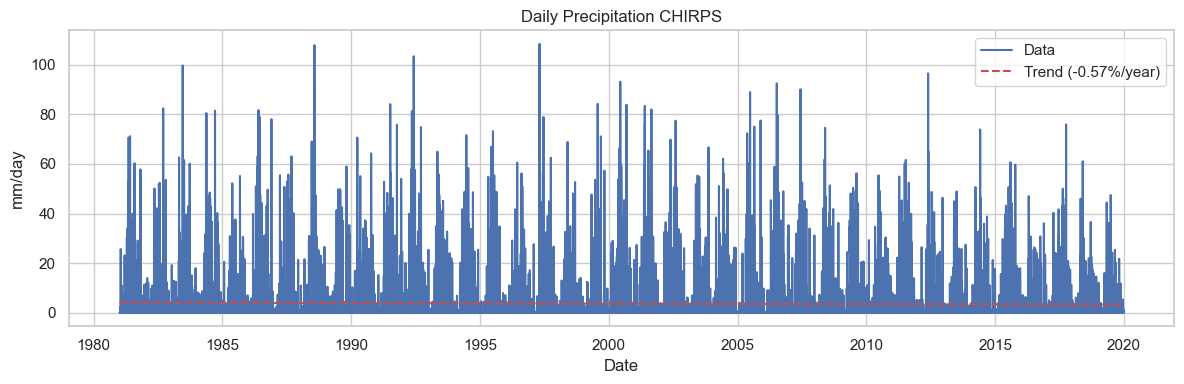

Daily Precipitation CHIRPS — Mean: 3.704 mm/day
Percent change per year (linear fit): -0.572%
Mean pre-2000: 3.736 mm/day
Mean post-2000: 3.674 mm/day
Percent difference (post2000 vs pre2000): -1.659%

Percent changes between consecutive decades:
  1980s to 1990s: -0.252%
  1990s to 2000s: 15.772%
  2000s to 2010s: -29.913%

----------------------------------------

--- Monthly Precipitation CHIRPS ---


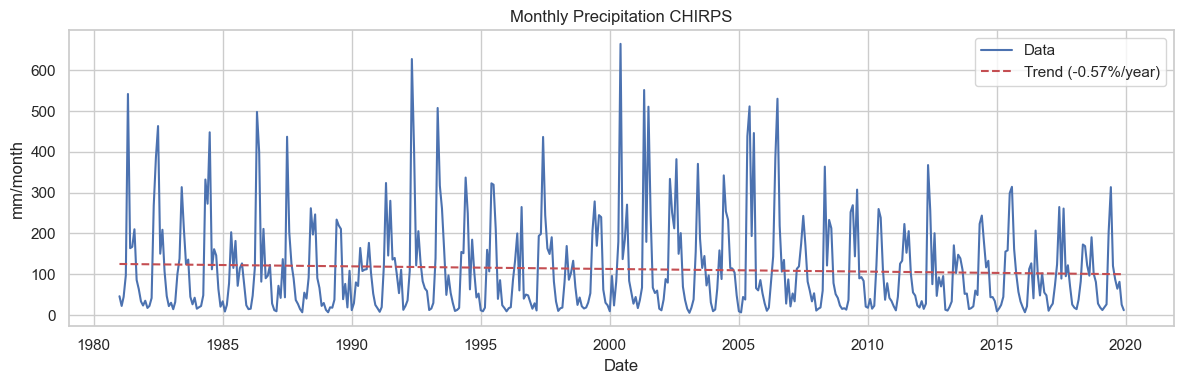

Monthly Precipitation CHIRPS — Mean: 112.735 mm/month
Percent change per year (linear fit): -0.571%
Mean pre-2000: 113.696 mm/month
Mean post-2000: 111.823 mm/month
Percent difference (post2000 vs pre2000): -1.648%

Percent changes between consecutive decades:
  1980s to 1990s: -0.258%
  1990s to 2000s: 15.804%
  2000s to 2010s: -29.932%

----------------------------------------

--- Daily Precipitation CR2MET ---


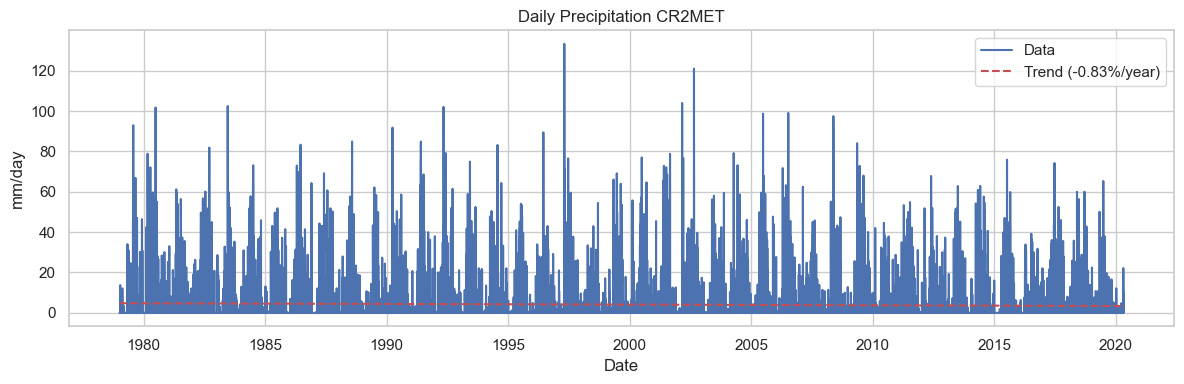

Daily Precipitation CR2MET — Mean: 4.065 mm/day
Percent change per year (linear fit): -0.827%
Mean pre-2000: 4.225 mm/day
Mean post-2000: 3.900 mm/day
Percent difference (post2000 vs pre2000): -7.688%

Percent changes between consecutive decades:
  1970s to 1980s: 2.305%
  1980s to 1990s: -14.039%
  1990s to 2000s: 13.041%
  2000s to 2010s: -20.523%
  2010s to 2020s: -79.217%

----------------------------------------

--- Monthly Precipitation CR2MET ---


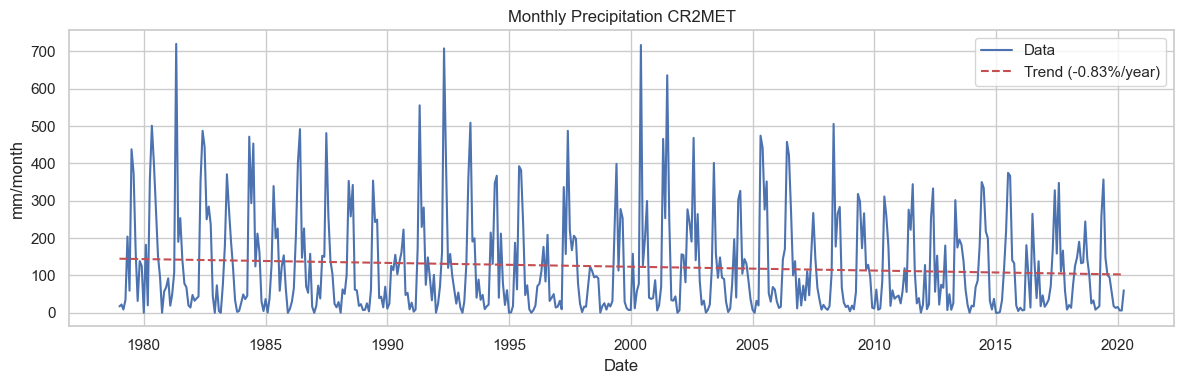

Monthly Precipitation CR2MET — Mean: 123.729 mm/month
Percent change per year (linear fit): -0.827%
Mean pre-2000: 128.597 mm/month
Mean post-2000: 118.702 mm/month
Percent difference (post2000 vs pre2000): -7.695%

Percent changes between consecutive decades:
  1970s to 1980s: 2.389%
  1980s to 1990s: -14.063%
  1990s to 2000s: 13.072%
  2000s to 2010s: -20.544%
  2010s to 2020s: -79.342%

----------------------------------------

--- Daily Max Temperature ---


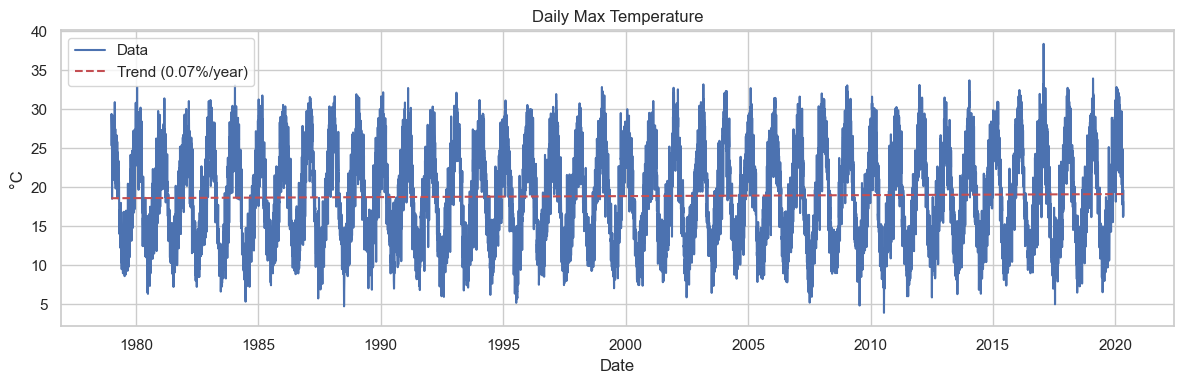

Daily Max Temperature — Mean: 18.853 °C
Percent change per year (linear fit): 0.068%
Mean pre-2000: 18.775 °C
Mean post-2000: 18.932 °C
Percent difference (post2000 vs pre2000): 0.837%

Percent changes between consecutive decades:
  1970s to 1980s: 0.466%
  1980s to 1990s: 0.350%
  1990s to 2000s: -0.689%
  2000s to 2010s: 1.431%
  2010s to 2020s: 36.427%

----------------------------------------

--- Daily Min Temperature ---


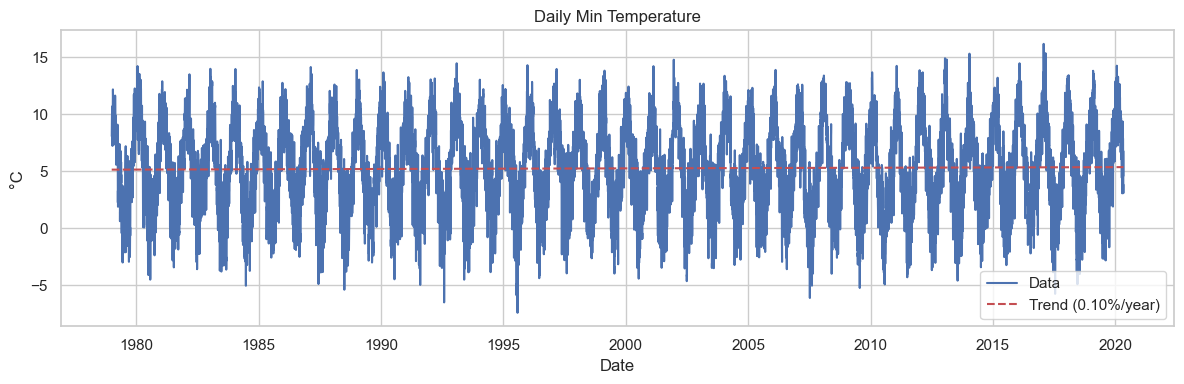

Daily Min Temperature — Mean: 5.249 °C
Percent change per year (linear fit): 0.102%
Mean pre-2000: 5.203 °C
Mean post-2000: 5.297 °C
Percent difference (post2000 vs pre2000): 1.809%

Percent changes between consecutive decades:
  1970s to 1980s: 3.125%
  1980s to 1990s: -0.494%
  1990s to 2000s: -0.542%
  2000s to 2010s: 2.521%
  2010s to 2020s: 71.873%

----------------------------------------

--- Daily Streamflow ---


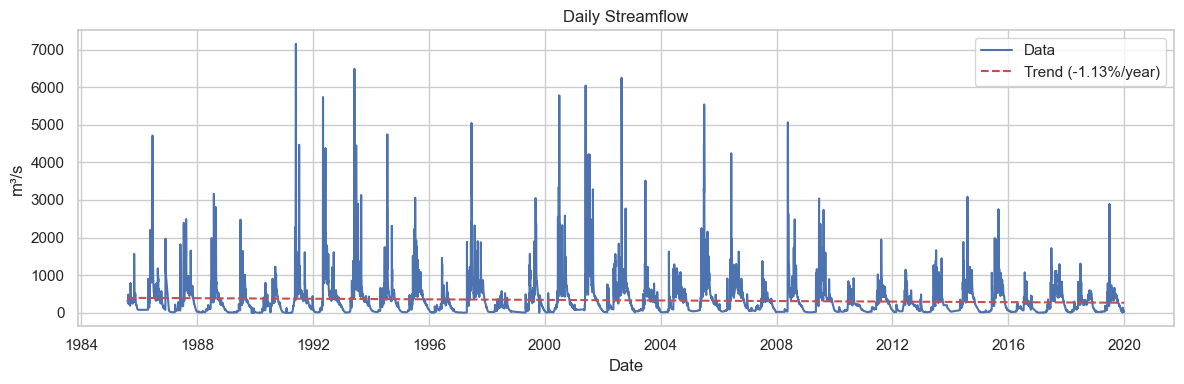

Daily Streamflow — Mean: 333.020 m³/s
Percent change per year (linear fit): -1.135%
Mean pre-2000: 356.346 m³/s
Mean post-2000: 316.646 m³/s
Percent difference (post2000 vs pre2000): -11.141%

Percent changes between consecutive decades:
  1980s to 1990s: 14.869%
  1990s to 2000s: 2.636%
  2000s to 2010s: -35.031%

----------------------------------------

--- Monthly Streamflow ---


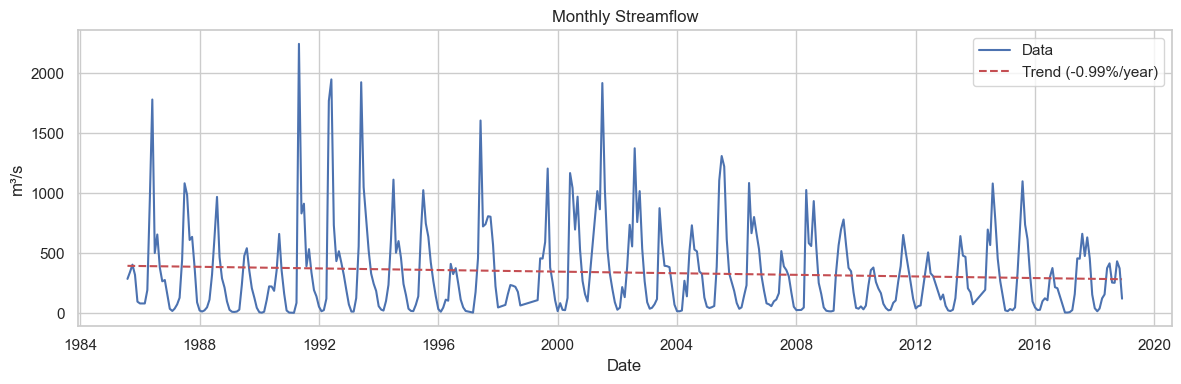

Monthly Streamflow — Mean: 338.307 m³/s
Percent change per year (linear fit): -0.990%
Mean pre-2000: 356.657 m³/s
Mean post-2000: 324.544 m³/s
Percent difference (post2000 vs pre2000): -9.004%

Percent changes between consecutive decades:
  1980s to 1990s: 18.851%
  1990s to 2000s: 2.304%
  2000s to 2010s: -33.996%

----------------------------------------

--- Annual Surface Water Rights ---


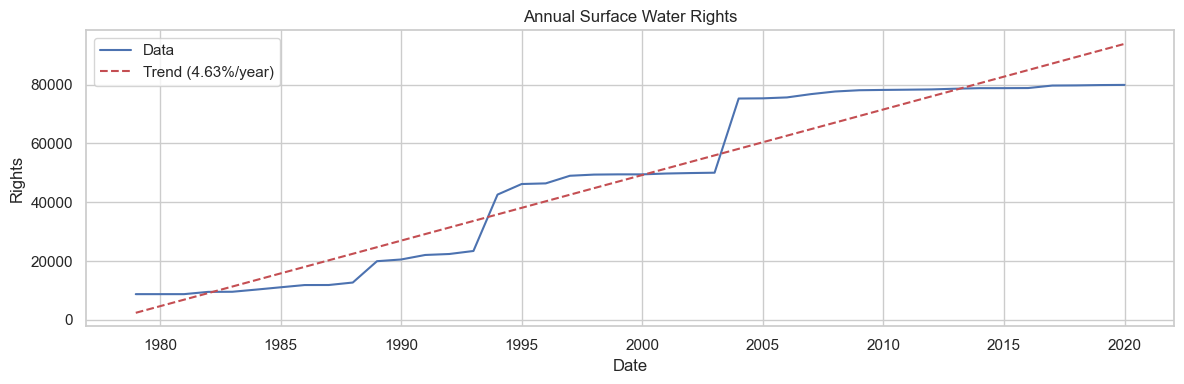

Annual Surface Water Rights — Mean: 48140.380 Rights
Percent change per year (linear fit): 4.634%
Mean pre-2000: 23558.216 Rights
Mean post-2000: 72722.543 Rights
Percent difference (post2000 vs pre2000): 208.693%

Percent changes between consecutive decades:
  1970s to 1980s: 30.625%
  1980s to 1990s: 224.938%
  1990s to 2000s: 77.086%
  2000s to 2010s: 19.929%
  2010s to 2020s: 1.255%

----------------------------------------

--- Annual Groundwater Water Rights ---


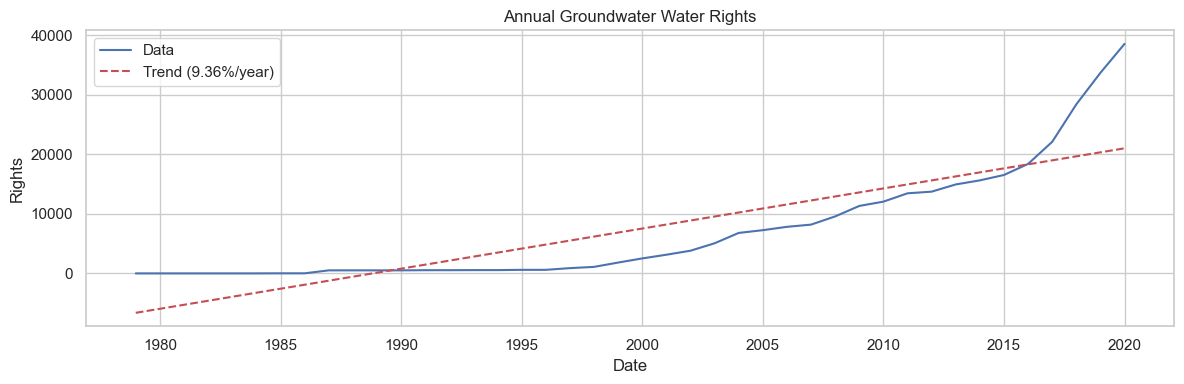

Annual Groundwater Water Rights — Mean: 7201.315 Rights
Percent change per year (linear fit): 9.365%
Mean pre-2000: 440.426 Rights
Mean post-2000: 13962.203 Rights
Percent difference (post2000 vs pre2000): 3070.158%

Percent changes between consecutive decades:
  1970s to 1980s: nan%
  1980s to 1990s: 394.153%
  1990s to 2000s: 752.064%
  2000s to 2010s: 188.483%
  2010s to 2020s: 104.051%

----------------------------------------



In [49]:
start_date = pd.Timestamp('1979-01-01')
end_date = pd.Timestamp('2020-12-31')

def load_data(filepath):
    # Read CSV, parse 'NA' as NaN, parse dates, filter by date range, drop NaNs
    df = pd.read_csv(filepath, na_values=['NA'])
    df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
    df = df.dropna(subset=[date_column, basin_col])
    df = df[(df[date_column] >= start_date) & (df[date_column] <= end_date)]
    df = df.set_index(date_column)
    df = df[[basin_col]]  # Keep only basin_col and index
    df = df.dropna()
    return df

def calculate_decade_means(df):
    df = df.copy()
    df['decade'] = (df.index.year // 10) * 10
    decade_means = df.groupby('decade')[basin_col].mean()
    decade_means = decade_means.dropna()  # remove empty decades
    return decade_means

def plot_percent_change(df, title, ylabel):
    df = df.sort_index()
    y = df[basin_col]
    x = (df.index - df.index[0]).days.values  # days since start
    
    # Linear regression for annual slope
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    mean_val = y.mean()
    pct_change_per_year = (slope * 365.25) / mean_val * 100 if mean_val != 0 else float('nan')
    
    # Means pre/post 2000
    pre_2000_mean = y[df.index < '2000-01-01'].mean()
    post_2000_mean = y[df.index >= '2000-01-01'].mean()
    pct_diff_pre_post_2000 = ((post_2000_mean - pre_2000_mean) / pre_2000_mean) * 100 if pre_2000_mean != 0 else float('nan')
    
    # Calculate actual percent changes between decades
    decade_means = calculate_decade_means(df)
    pct_changes_decades = {}
    decades = sorted(decade_means.index)
    for i in range(len(decades) - 1):
        start_decade = decades[i]
        end_decade = decades[i+1]
        start_mean = decade_means[start_decade]
        end_mean = decade_means[end_decade]
        if start_mean != 0:
            pct_changes_decades[f"{start_decade}s to {end_decade}s"] = ((end_mean - start_mean) / start_mean) * 100
        else:
            pct_changes_decades[f"{start_decade}s to {end_decade}s"] = float('nan')
    
    # Plot
    plt.figure(figsize=(12,4))
    plt.plot(df.index, y, label='Data')
    plt.plot(df.index, intercept + slope * x, 'r--', label=f'Trend ({pct_change_per_year:.2f}%/year)')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"{title} — Mean: {mean_val:.3f} {ylabel}")
    print(f"Percent change per year (linear fit): {pct_change_per_year:.3f}%")
    print(f"Mean pre-2000: {pre_2000_mean:.3f} {ylabel}")
    print(f"Mean post-2000: {post_2000_mean:.3f} {ylabel}")
    print(f"Percent difference (post2000 vs pre2000): {pct_diff_pre_post_2000:.3f}%\n")
    
    print("Percent changes between consecutive decades:")
    for k, v in pct_changes_decades.items():
        print(f"  {k}: {v:.3f}%")
    print('\n' + '-'*40 + '\n')

# === Run analysis and plot ===

datasets = {
    'Daily Precipitation CHIRPS': (daily_precip_chirps, 'mm/day'),
    'Monthly Precipitation CHIRPS': (monthly_precip_chirps, 'mm/month'),
    'Daily Precipitation CR2MET': (daily_precip_cr2, 'mm/day'),
    'Monthly Precipitation CR2MET': (monthly_precip_cr2, 'mm/month'),
    'Daily Max Temperature': (tmax_daily, '°C'),
    'Daily Min Temperature': (tmin_daily, '°C'),
    'Daily Streamflow': (streamflow_daily, 'm³/s'),
    'Monthly Streamflow': (streamflow_monthly, 'm³/s'),
    'Annual Surface Water Rights': (surface_rights, 'Rights'),
    'Annual Groundwater Water Rights': (groundwater_rights, 'Rights'),
}

for name, (filepath, unit) in datasets.items():
    print(f"--- {name} ---")
    df = load_data(filepath)
    plot_percent_change(df, name, unit)


# compare values between decades and pre vs post 2000:


Precipitation (CR2MET) (mm):
Mean before 2000: 1543.16
Mean after 2000: 1379.20


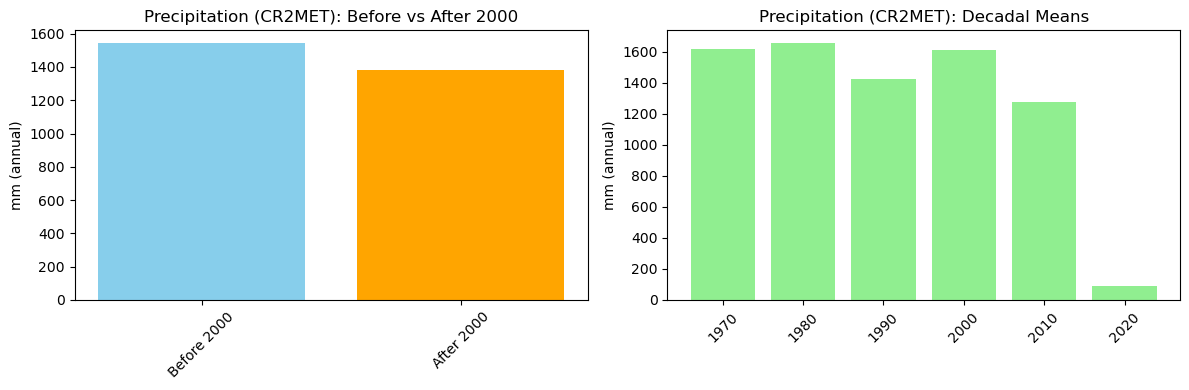


Precipitation (CHIRPS) (mm):
Mean before 2000: 1364.36
Mean after 2000: 1341.87


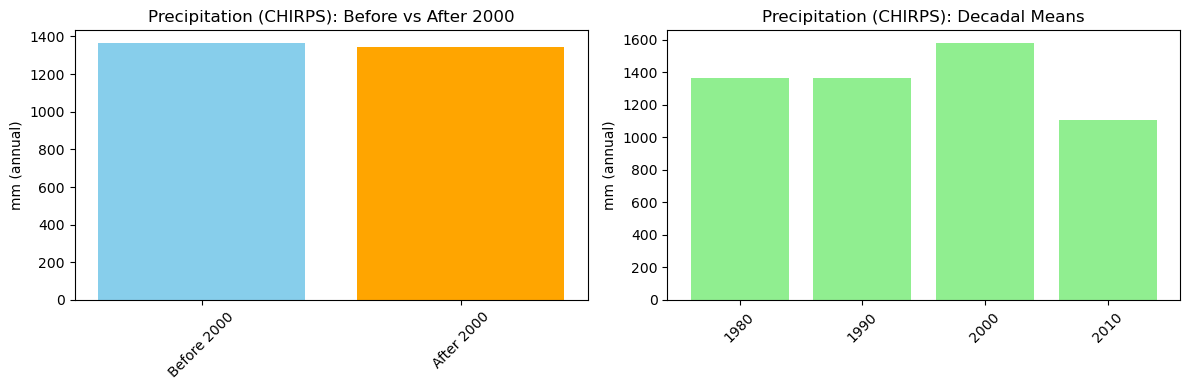


Max Temperature (Tmax) (°C):
Mean before 2000: 18.81
Mean after 2000: 19.19


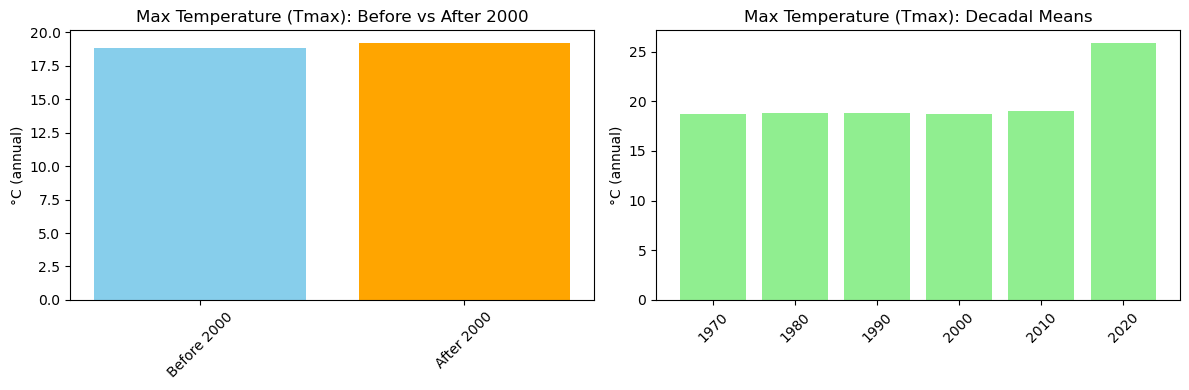


Min Temperature (Tmin) (°C):
Mean before 2000: 5.22
Mean after 2000: 5.44


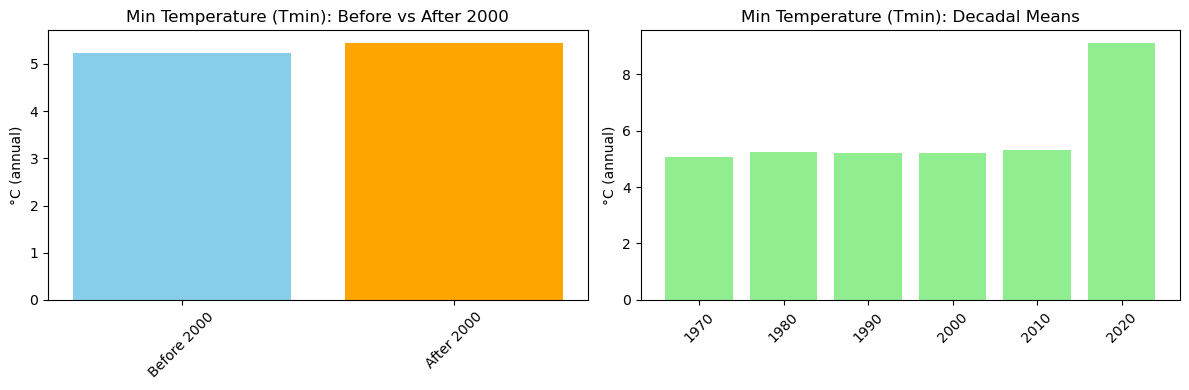


Streamflow Volume (m³):
Mean before 2000: 10171618894.08
Mean after 2000: 9752280563.37


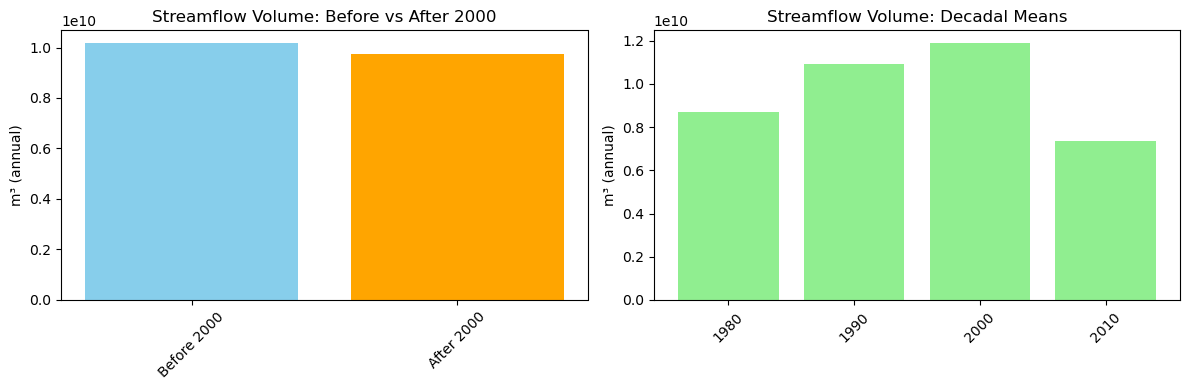


Groundwater Rights (L/s):
Mean before 2000: 84.85
Mean after 2000: 15174.84


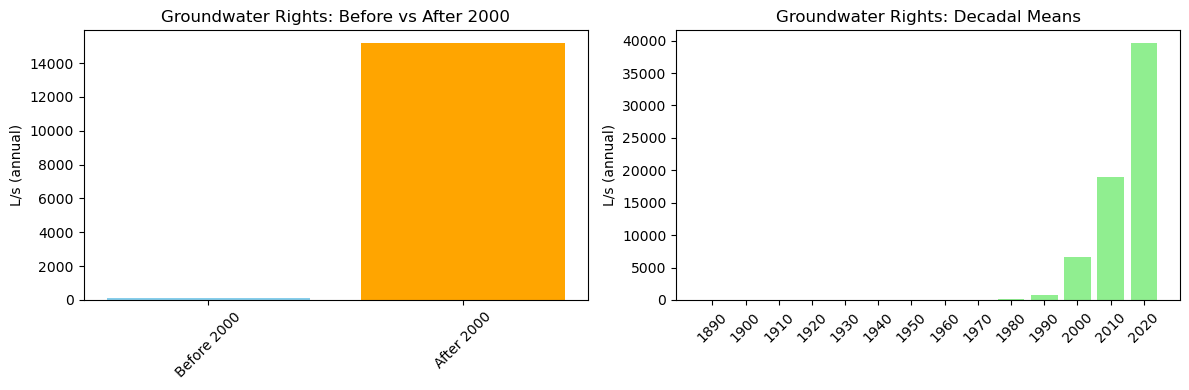


Surface Water Rights (L/s):
Mean before 2000: 8093.19
Mean after 2000: 73050.58


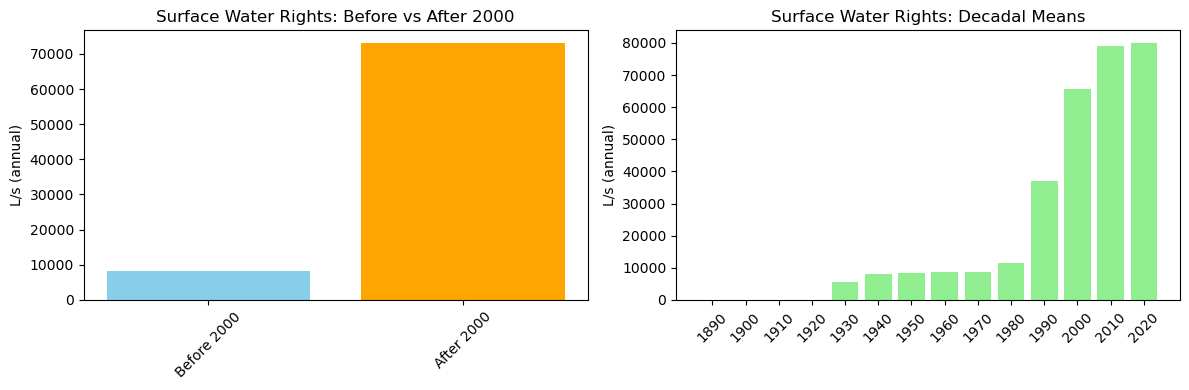

In [20]:
# Helper function to group by year and calculate annual sums or means
def process_monthly_csv(filepath, value_col, agg='sum'):
    df = pd.read_csv(filepath, parse_dates=[date_column])
    df = df[[date_column, basin_col]].dropna()
    df['year'] = df[date_column].dt.year
    if agg == 'sum':
        df_annual = df.groupby('year')[basin_col].sum()
    else:
        df_annual = df.groupby('year')[basin_col].mean()
    return df_annual

# Process annual water rights
def process_annual_csv(filepath):
    df = pd.read_csv(filepath)
    df = df[['year', basin_col]].dropna()
    df.set_index('year', inplace=True)
    return df[basin_col]

# Compute means before/after 2000 and by decade
def analyze_and_plot(data, label, units):
    before_2000 = data[data.index < 2000]
    after_2000 = data[data.index >= 2000]

    mean_before = before_2000.mean()
    mean_after = after_2000.mean()

    print(f"\n{label} ({units}):")
    print(f"Mean before 2000: {mean_before:.2f}")
    print(f"Mean after 2000: {mean_after:.2f}")

    # Decadal averages
    decades = (data.index // 10) * 10
    df_decades = data.groupby(decades).mean()

    # Plotting
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].bar(['Before 2000', 'After 2000'], [mean_before, mean_after], color=['skyblue', 'orange'])
    axs[0].set_title(f'{label}: Before vs After 2000')
    axs[0].set_ylabel(f'{units} (annual)')

    axs[1].bar(df_decades.index.astype(str), df_decades.values, color='lightgreen')
    axs[1].set_title(f'{label}: Decadal Means')
    axs[1].set_ylabel(f'{units} (annual)')

    for ax in axs:
        ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()

# === Run analysis === #

# Precipitation (CR2, CHIRPS)
precip_cr2 = process_monthly_csv(monthly_precip_cr2, basin_col, agg='sum')
analyze_and_plot(precip_cr2, 'Precipitation (CR2MET)', 'mm')

precip_chirps = process_monthly_csv(monthly_precip_chirps, basin_col, agg='sum')
analyze_and_plot(precip_chirps, 'Precipitation (CHIRPS)', 'mm')

# Tmax and Tmin (use mean, not sum)
tmax = process_monthly_csv(tmax_monthly, basin_col, agg='mean')
analyze_and_plot(tmax, 'Max Temperature (Tmax)', '°C')

tmin = process_monthly_csv(tmin_monthly, basin_col, agg='mean')
analyze_and_plot(tmin, 'Min Temperature (Tmin)', '°C')

# Streamflow (convert monthly m³/s → total annual volume)
streamflow = pd.read_csv(streamflow_monthly, parse_dates=[date_column])
streamflow = streamflow[[date_column, basin_col]].dropna()
streamflow['year'] = streamflow[date_column].dt.year
streamflow['days_in_month'] = streamflow[date_column].dt.days_in_month
# m³/s × seconds in month → m³ per month
streamflow['monthly_volume_m3'] = streamflow[basin_col] * streamflow['days_in_month'] * 86400
streamflow_annual = streamflow.groupby('year')['monthly_volume_m3'].sum()
analyze_and_plot(streamflow_annual, 'Streamflow Volume', 'm³')

# Water rights (already annual)
gw_rights = process_annual_csv(groundwater_rights)
analyze_and_plot(gw_rights, 'Groundwater Rights', 'L/s')

sf_rights = process_annual_csv(surface_rights)
analyze_and_plot(sf_rights, 'Surface Water Rights', 'L/s')


=== Before / After 2000 Analysis ===


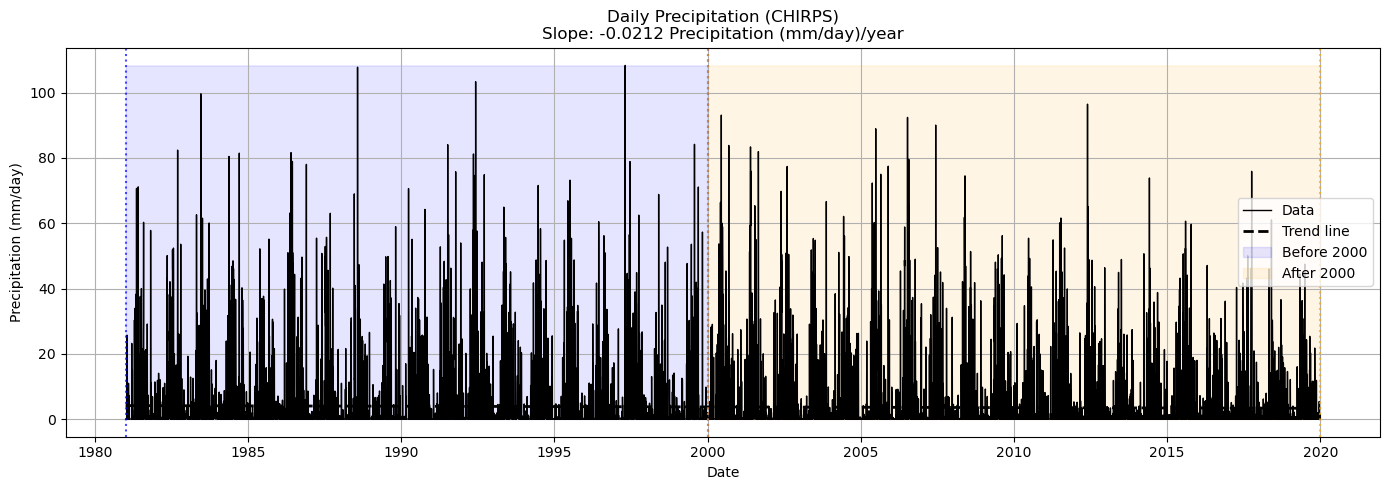

Daily Precipitation (CHIRPS) - slope: -0.0212 Precipitation (mm/day)/year
Mean for Before 2000 (1981-01-01 to 1999-12-31): 3.736 Precipitation (mm/day)
Mean for After 2000 (2000-01-01 to 2019-12-31): 3.674 Precipitation (mm/day)

Differences between consecutive periods:
  After 2000 minus Before 2000: -0.062 Precipitation (mm/day)

=== Decadal Analysis ===


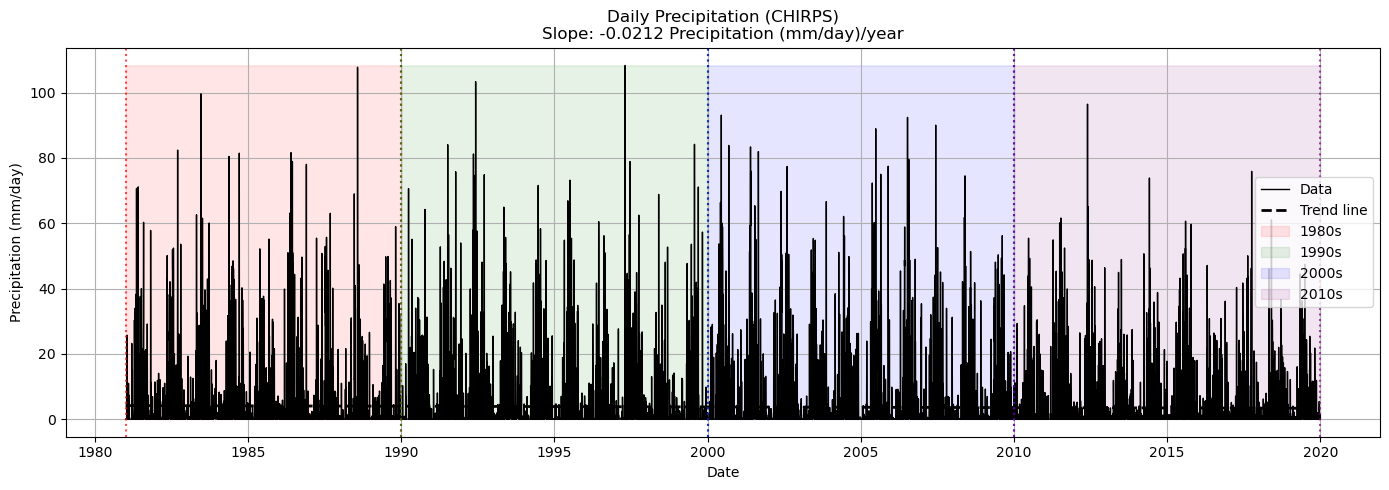

Daily Precipitation (CHIRPS) - slope: -0.0212 Precipitation (mm/day)/year
Mean for 1980s (1981-01-01 to 1989-12-31): 3.741 Precipitation (mm/day)
Mean for 1990s (1990-01-01 to 1999-12-31): 3.731 Precipitation (mm/day)
Mean for 2000s (2000-01-01 to 2009-12-31): 4.320 Precipitation (mm/day)
Mean for 2010s (2010-01-01 to 2019-12-31): 3.028 Precipitation (mm/day)

Differences between consecutive periods:
  1990s minus 1980s: -0.009 Precipitation (mm/day)
  2000s minus 1990s: 0.589 Precipitation (mm/day)
  2010s minus 2000s: -1.292 Precipitation (mm/day)


In [ ]:
# Example for one variable - change paths for others as needed
daily_precip_chirps = '/Users/milliespencer/Downloads/camels_cl_8141001/precip_chirps_day.csv'
basin_col = '8141001'
date_column = 'date'

# -------- FUNCTIONS --------

def load_and_prepare(file, basin_col, new_colname):
    df = pd.read_csv(file)
    df[date_column] = pd.to_datetime(df[date_column])
    df = df.rename(columns={basin_col: new_colname})
    df = df[[date_column, new_colname]].dropna()
    df.set_index(date_column, inplace=True)
    return df

def linear_trend_slope(df):
    x = df.index.map(pd.Timestamp.toordinal).values.reshape(-1, 1)
    y = df.iloc[:, 0].values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(x, y)
    slope_per_day = model.coef_[0][0]
    intercept = model.intercept_[0]
    return slope_per_day, intercept, model.predict(x)

def plot_with_trends_and_periods(df, title, ylabel, color, periods):
    """
    periods: list of tuples [(start_date, end_date, label, color), ...]
    """
    plt.figure(figsize=(14,5))
    plt.plot(df.index, df.iloc[:,0], label='Data', color=color, linewidth=1)
    
    # Trend line and slope
    slope_per_day, intercept, y_trend = linear_trend_slope(df)
    plt.plot(df.index, y_trend, linestyle='--', color='black', linewidth=2, label='Trend line')
    
    days_per_year = 365.25
    slope_per_year = slope_per_day * days_per_year
    
    # Mark periods on the plot with vertical lines and shaded areas
    for start, end, label, col in periods:
        plt.axvline(start, color=col, linestyle=':', alpha=0.7)
        plt.axvline(end, color=col, linestyle=':', alpha=0.7)
        plt.fill_between(df.index, df.iloc[:,0].min(), df.iloc[:,0].max(),
                         where=(df.index >= start) & (df.index <= end),
                         color=col, alpha=0.1, label=label)
    
    plt.title(f"{title}\nSlope: {slope_per_year:.4f} {ylabel}/year")
    plt.xlabel('Date')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Compute mean per period and differences
    print(f"{title} - slope: {slope_per_year:.4f} {ylabel}/year")
    
    means = {}
    for start, end, label, _ in periods:
        period_mean = df.loc[(df.index >= start) & (df.index <= end)].iloc[:,0].mean()
        means[label] = period_mean
        print(f"Mean for {label} ({start.date()} to {end.date()}): {period_mean:.3f} {ylabel}")
    
    # Print differences between periods
    labels = list(means.keys())
    print("\nDifferences between consecutive periods:")
    for i in range(len(labels)-1):
        diff = means[labels[i+1]] - means[labels[i]]
        print(f"  {labels[i+1]} minus {labels[i]}: {diff:.3f} {ylabel}")

# -------- MAIN --------

# Load your variable of interest here
df = load_and_prepare(daily_precip_chirps, basin_col, 'Precipitation (mm/day)')

# Define periods for before/after 2000 comparison
before_after_2000 = [
    (df.index.min(), pd.Timestamp('1999-12-31'), 'Before 2000', 'blue'),
    (pd.Timestamp('2000-01-01'), df.index.max(), 'After 2000', 'orange'),
]

# Define decades (approximate ranges)
decades = [
    (pd.Timestamp('1981-01-01'), pd.Timestamp('1989-12-31'), '1980s', 'red'),
    (pd.Timestamp('1990-01-01'), pd.Timestamp('1999-12-31'), '1990s', 'green'),
    (pd.Timestamp('2000-01-01'), pd.Timestamp('2009-12-31'), '2000s', 'blue'),
    (pd.Timestamp('2010-01-01'), pd.Timestamp('2019-12-31'), '2010s', 'purple'),
]

print("=== Before / After 2000 Analysis ===")
plot_with_trends_and_periods(df, 'Daily Precipitation (CHIRPS)', 'Precipitation (mm/day)', 'black', before_after_2000)

print("\n=== Decadal Analysis ===")
plot_with_trends_and_periods(df, 'Daily Precipitation (CHIRPS)', 'Precipitation (mm/day)', 'black', decades)


# Compare CHIRPS and CR2 precipitation datasets: 

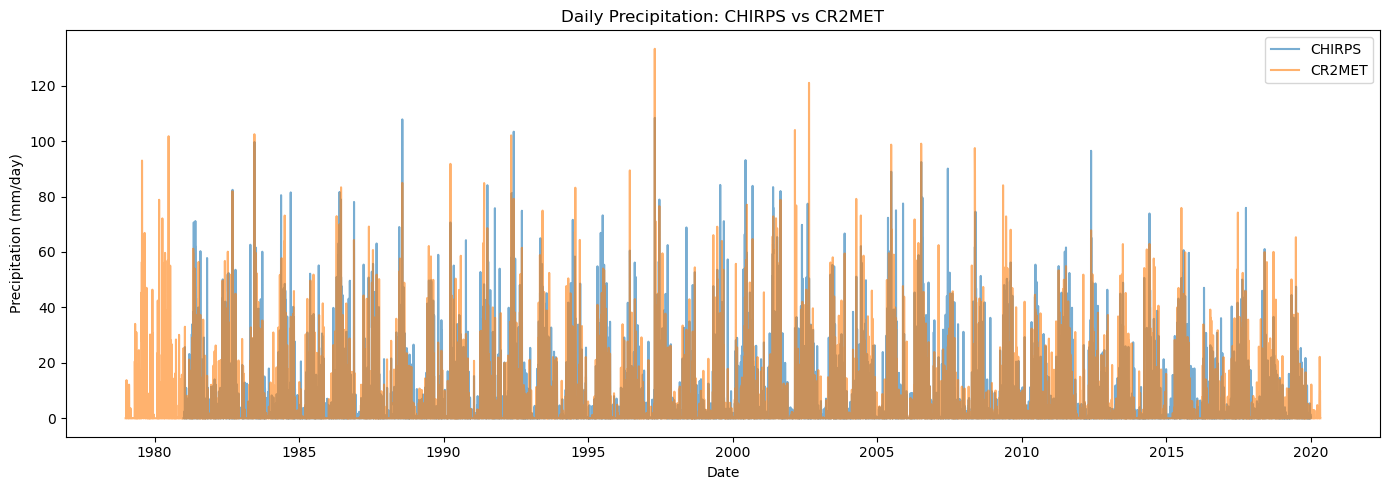

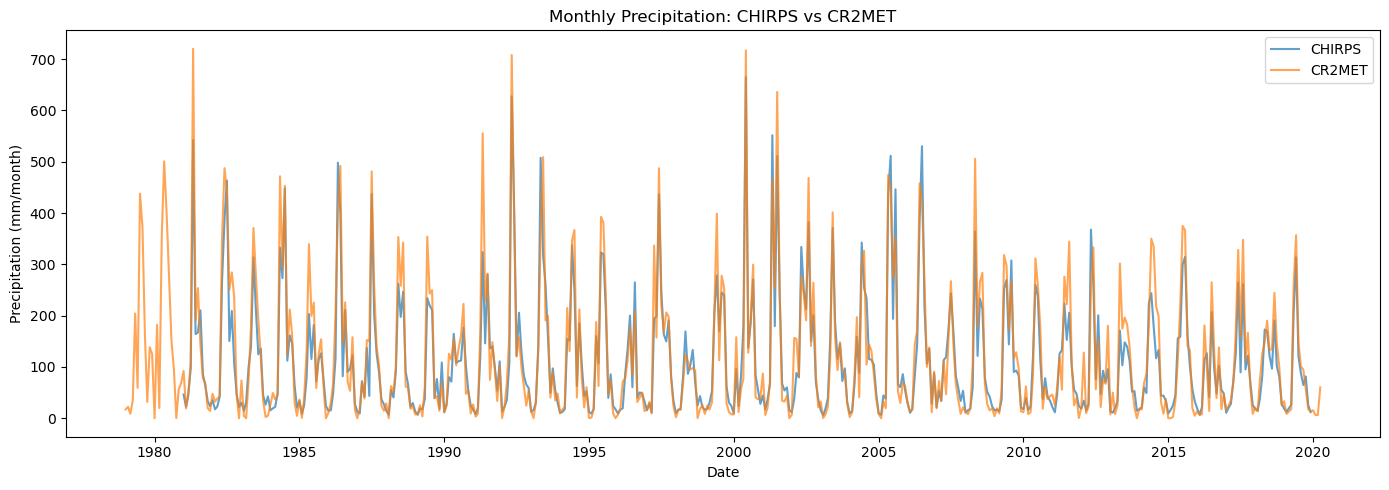

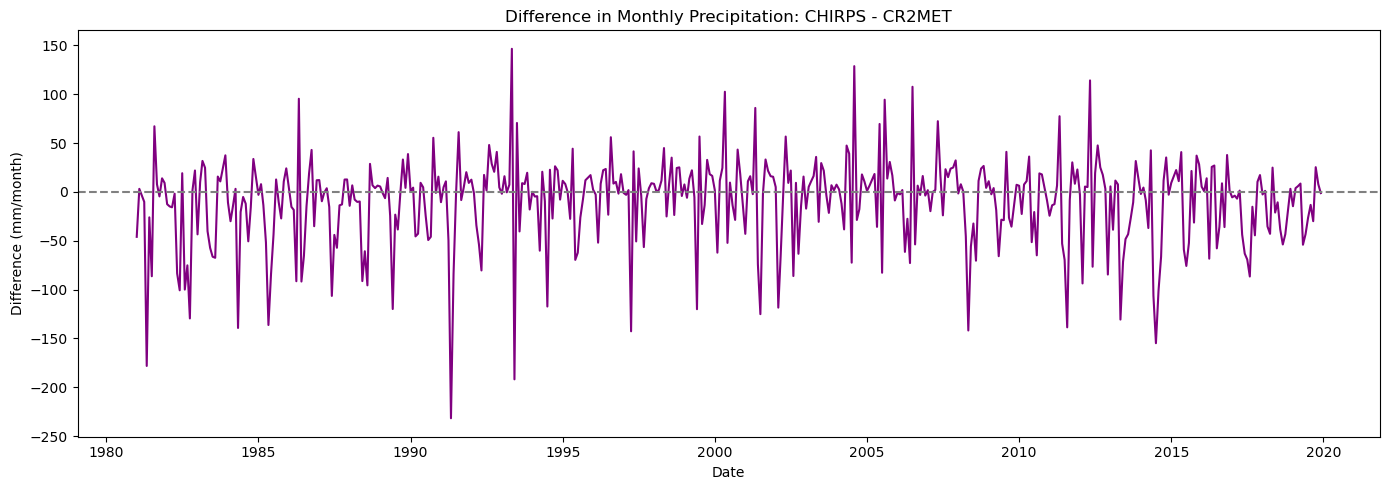

=== Monthly Precipitation Comparison ===
Mean CHIRPS: 112.73547863247863
Mean CR2MET: 124.55616489496677
Mean Difference (CHIRPS - CR2MET): -10.243745915436628


In [28]:
# === Load data ===
def load_precip(path, basin_col='8141001', new_colname='precip'):
    df = pd.read_csv(path, parse_dates=['date'])
    df = df.rename(columns={basin_col: new_colname})
    return df[['date', new_colname]]

df_daily_chirps = load_precip(daily_precip_chirps, new_colname='chirps')
df_monthly_chirps = load_precip(monthly_precip_chirps, new_colname='chirps')
df_daily_cr2 = load_precip(daily_precip_cr2, new_colname='cr2')
df_monthly_cr2 = load_precip(monthly_precip_cr2, new_colname='cr2')

# === Plot Daily Comparison ===
plt.figure(figsize=(14, 5))
plt.plot(df_daily_chirps['date'], df_daily_chirps['chirps'], label='CHIRPS', alpha=0.6)
plt.plot(df_daily_cr2['date'], df_daily_cr2['cr2'], label='CR2MET', alpha=0.6)
plt.title('Daily Precipitation: CHIRPS vs CR2MET')
plt.ylabel('Precipitation (mm/day)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

# === Plot Monthly Comparison ===
plt.figure(figsize=(14, 5))
plt.plot(df_monthly_chirps['date'], df_monthly_chirps['chirps'], label='CHIRPS', alpha=0.7)
plt.plot(df_monthly_cr2['date'], df_monthly_cr2['cr2'], label='CR2MET', alpha=0.7)
plt.title('Monthly Precipitation: CHIRPS vs CR2MET')
plt.ylabel('Precipitation (mm/month)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

# === Difference Over Time (Monthly) ===
df_monthly = pd.merge(df_monthly_chirps, df_monthly_cr2, on='date', how='inner')
df_monthly['difference'] = df_monthly['chirps'] - df_monthly['cr2']

plt.figure(figsize=(14, 5))
plt.plot(df_monthly['date'], df_monthly['difference'], color='purple')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Difference in Monthly Precipitation: CHIRPS - CR2MET')
plt.ylabel('Difference (mm/month)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

# === Summary Stats ===
print("=== Monthly Precipitation Comparison ===")
print("Mean CHIRPS:", df_monthly['chirps'].mean())
print("Mean CR2MET:", df_monthly['cr2'].mean())
print("Mean Difference (CHIRPS - CR2MET):", df_monthly['difference'].mean())


## CR2met mean monthly precipitation is about 10mm grater than that reported by CHIRPS 

# Compare mean annual specific mass balance to streamflow 

In [31]:

# --- USER INPUTS ---
streamflow_monthly = '/Users/milliespencer/Downloads/camels_cl_8141001/q_m3s_mon.csv'  # Monthly streamflow CSV
mb_mwe_per_year = 0.20  # Mean annual specific mass balance (m w.e./yr)
glacier_area_m2 = 1_907_100  # Glacier area in m²

# --- LOAD STREAMFLOW DATA ---
df = pd.read_csv(streamflow_monthly, parse_dates=['date'])

# Rename streamflow column for easier use
basin_col = '8141001'
df = df.rename(columns={basin_col: 'flow_m3s'})

# Add days in each month and convert to seconds
df['days_in_month'] = df['date'].dt.days_in_month
df['seconds_in_month'] = df['days_in_month'] * 24 * 3600

# Calculate monthly volume (m³) = flow rate (m³/s) * seconds in month
df['volume_m3'] = df['flow_m3s'] * df['seconds_in_month']

# Extract year for grouping
df['year'] = df['date'].dt.year

# Sum monthly volumes by year -> annual volume (m³)
annual_volumes = df.groupby('year')['volume_m3'].sum().reset_index()

# Calculate average annual streamflow volume (m³)
mean_annual_volume_m3 = annual_volumes['volume_m3'].mean()

# Convert to average annual flow rate (m³/s)
seconds_per_year = 365.25 * 24 * 3600
mean_annual_flow_m3s = mean_annual_volume_m3 / seconds_per_year

print(f"Mean annual streamflow volume: {mean_annual_volume_m3:,.0f} m³/year")
print(f"Mean annual streamflow rate: {mean_annual_flow_m3s:.3f} m³/s")

# --- GLACIER MASS BALANCE TO FLOW ---
# Glacier melt volume (m³/year)
annual_glacier_volume_m3 = mb_mwe_per_year * glacier_area_m2

# Glacier average discharge (m³/s)
avg_glacier_discharge_m3s = annual_glacier_volume_m3 / seconds_per_year

print(f"Average glacier discharge: {avg_glacier_discharge_m3s:.3f} m³/s")

# --- PERCENT CONTRIBUTION ---
percent_contribution = (avg_glacier_discharge_m3s / mean_annual_flow_m3s) * 100

print(f"Estimated glacier contribution to annual streamflow: {percent_contribution:.1f}%")


Mean annual streamflow volume: 8,044,467,003 m³/year
Mean annual streamflow rate: 254.914 m³/s
Average glacier discharge: 0.012 m³/s
Estimated glacier contribution to annual streamflow: 0.0%


## tiny compared to whole basin, better to compare with smaller basin area 